# 07 - Đánh giá sự dịch chuyển khái niệm (Concept Drift)

### Khoảng trống nghiên cứu giải quyết (Research Gap):
- Bài báo gốc tự thừa nhận một hạn chế rất lớn tại Section 5.1: *"the current implementation is evaluated under offline conditions; real-time performance under continuous streaming conditions is yet to be assessed"*.
- Notebook này lấp đầy khoảng trống đó bằng cách **thiết lập mô phỏng Concept Drift thời gian thực** trên dữ liệu mạng chạy trực tuyến, ứng dụng thuật toán kiểm định thống kê **Kolmogorov-Smirnov (KS-test)** để phát hiện sự dịch chuyển phân phối đầu vào (Covariate Shift) và đo lường độ trễ phát hiện, cũng như mức độ sụt giảm độ chính xác của mô hình CyberDetect-MLP.

In [1]:
# === Thiết lập môi trường ỔN ĐỊNH + CHỐNG RỚT DRIVE (auto-retry remount) ===
# Làm việc trên Ổ CỨNG LOCAL /content; kéo dữ liệu từ Drive có thử lại khi mount rớt.
import os, time, shutil
from contextlib import contextmanager

DRIVE = '/content/drive/MyDrive/Nhom28_CyberDetect_MLP_Final'
PROJECT_PATH = '/content/cdmlp'
NEED_RAW = False   # True chi voi notebook 08
ON_COLAB = False

def _mount():
    from google.colab import drive
    drive.mount('/content/drive', force_remount=True)

try:
    _mount(); ON_COLAB = True
except Exception:
    here = os.getcwd()
    while here != os.path.dirname(here) and not os.path.isdir(os.path.join(here, 'notebooks')):
        here = os.path.dirname(here)
    DRIVE = here; PROJECT_PATH = here

def _pull(rel):
    s = os.path.join(DRIVE, rel); d = os.path.join(PROJECT_PATH, rel)
    if os.path.isdir(s): shutil.copytree(s, d, dirs_exist_ok=True)
    elif os.path.isfile(s):
        os.makedirs(os.path.dirname(d), exist_ok=True); shutil.copy2(s, d)

if ON_COLAB:
    os.makedirs(PROJECT_PATH, exist_ok=True)
    rels = ['scripts', 'src', 'models', 'results', 'data/colab_processed', 'data/ton_iot.csv']
    if NEED_RAW: rels.append('data/raw')
    # ton_iot.csv là item CUỐI -> nếu nó có mặt tức là đã kéo xong toàn bộ list
    sentinel = os.path.join(PROJECT_PATH, 'data', 'ton_iot.csv')
    ok = False
    for attempt in range(1, 6):
        for rel in rels:
            try: _pull(rel)
            except Exception as e: print(f'  (loi pull {rel}, thu lai sau): {str(e)[:70]}')
        if os.path.exists(sentinel):
            ok = True; break
        print(f'  [retry {attempt}/5] Drive rot khi keo du lieu -> remount + thu lai...')
        try: _mount()
        except Exception: pass
        time.sleep(3)
    if not ok:
        print('  [CANH BAO] Drive khong on dinh. Hay Runtime > Restart session roi chay lai cell nay.')
    else:
        print('  [OK] Da keo du lieu tu Drive ve local.')

os.makedirs(PROJECT_PATH, exist_ok=True); os.chdir(PROJECT_PATH)
try:
    get_ipython().run_line_magic('cd', PROJECT_PATH)
except Exception:
    pass
for d in ('data/colab_processed', 'results', 'results/xai', 'models'):
    os.makedirs(d, exist_ok=True)
print('PROJECT_PATH (local) =', PROJECT_PATH, '| ON_COLAB =', ON_COLAB)

def find_data_csv():
    for c in ['data/ton_iot.csv', 'data/raw/ton_iot.csv', 'ton_iot.csv']:
        if os.path.exists(c): return c
    raise FileNotFoundError('Khong tim thay ton_iot.csv (Drive: data/ton_iot.csv).')

@contextmanager
def step(name):
    t0=time.time(); print(f'\n[START] {name}', flush=True)
    try: yield
    finally: print(f'[DONE] {name} - {time.time()-t0:.1f}s', flush=True)

def sync_to_drive(retries=5):
    if not ON_COLAB:
        print('[local] bo qua sync Drive'); return
    for attempt in range(1, retries + 1):
        try:
            for rel in ['data/colab_processed', 'models', 'results']:
                s = os.path.join(PROJECT_PATH, rel)
                if os.path.exists(s): shutil.copytree(s, os.path.join(DRIVE, rel), dirs_exist_ok=True)
            print('[OK] Da dong bo ket qua ve Drive:', DRIVE); return
        except Exception as e:
            print(f'  [retry sync {attempt}/{retries}] Drive rot -> remount: {str(e)[:70]}')
            try: _mount()
            except Exception: pass
            time.sleep(3)
    print('  [CANH BAO] Sync Drive that bai. Ket qua van o local /content/cdmlp.')


Mounted at /content/drive
  [OK] Da keo du lieu tu Drive ve local.
/content
PROJECT_PATH (local) = /content/cdmlp | ON_COLAB = True


In [2]:
# Cài đặt các thư viện bổ trợ cần thiết
!pip -q install imbalanced-learn pyarrow joblib psutil tqdm scipy


In [3]:
# Thêm project root vào system path để import mô hình và modules
import sys
if os.getcwd() not in sys.path:
    sys.path.insert(0, os.getcwd())

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## 1. Chạy mô phỏng Concept Drift trên luồng gói tin

Chúng ta sẽ chạy script mô phỏng drift. Kịch bản mô phỏng sẽ:
1. Đọc tập dữ liệu TON_IoT Network.
2. Tạo luồng dữ liệu liên tục gồm 20,000 dòng gói tin mạng.
3. Giai đoạn 1 (t < 10,000): Môi trường mạng bình thường, ổn định.
4. Giai đoạn 2 (t >= 10,000): Tiêm Concept Drift bằng cách thay đổi hành vi tấn công dồn dập và nhân giá trị lưu lượng gói tin mạng lên gấp 50 lần (tạo Covariate Shift).
5. Chạy thuật toán cửa sổ trượt (window=1000, step=100) để đánh giá độ chính xác thực tế của MLP và tính chỉ số dịch chuyển KS statistic.

In [4]:
# Thực thi kịch bản mô phỏng và phân tích Concept Drift
!python scripts/concept_drift_analysis.py

2026-06-03 11:47:27.648612: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
  PHAN TICH CONCEPT DRIFT (DO THAT TU MO HINH DA TRAIN)
2026-06-03 11:47:32.321355: W tensorflow/core/common_runtime/gpu/gpu_bfc_allocator.cc:47] Overriding orig_value setting because the TF_FORCE_GPU_ALLOW_GROWTH environment variable is set. Original config value was 0.
I0000 00:00:1780487252.322823    4385 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
[*] Model da train: 10 lop | Du lieu: /content/cdmlp/data/ton_iot.csv

[*] Tao luong streaming: Pha 1 (on dinh) + Pha 2 (drift + covariate shift)...
    - Pha 1: 10000 goi | Pha 2: 10000 

## 2. Trực quan hóa kết quả phát hiện trôi dạt dữ liệu

Hiển thị bảng chỉ số đo lường Concept Drift theo thời gian thực:

In [5]:
metrics_csv = 'results/concept_drift_metrics.csv'
if os.path.exists(metrics_csv):
    df_drift = pd.read_csv(metrics_csv)
    print('Bảng dữ liệu chỉ số drift mẫu (5 dòng đầu và cuối):')
    display(pd.concat([df_drift.head(5), df_drift.tail(5)]))
else:
    print('Không tìm thấy tệp kết quả metrics!')

Bảng dữ liệu chỉ số drift mẫu (5 dòng đầu và cuối):


,Index,RollingAccuracy,KSStatistic,PValue
0,1000,0.875,0.000,1.000000e+00
1,1100,0.884,0.009,1.000000e+00
2,1200,0.882,0.005,1.000000e+00
3,1300,0.892,0.009,1.000000e+00
4,1400,0.888,0.014,9.999734e-01
185,19500,0.738,0.301,2.276863e-40
186,19600,0.737,0.303,6.548081e-41
187,19700,0.725,0.319,2.229756e-45
188,19800,0.718,0.313,1.128620e-43
189,19900,0.720,0.311,4.101461e-43


Hiển thị biểu đồ kết hợp thể hiện sự dịch chuyển phân phối (KS statistic) và mức sụt giảm độ chính xác trượt (Rolling Accuracy):

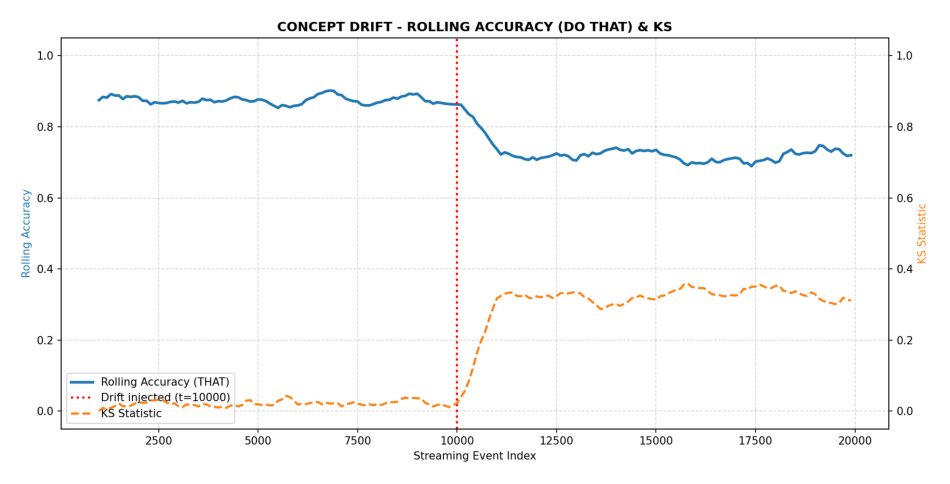

In [6]:
from PIL import Image
img_path = 'results/concept_drift_analysis.png'
if os.path.exists(img_path):
    img = Image.open(img_path)
    plt.figure(figsize=(12, 8))
    plt.imshow(img)
    plt.axis('off')
    plt.show()
else:
    print('Không tìm thấy hình ảnh biểu đồ phân tích trôi dạt!')

### Nhận xét & Đóng góp (theo số liệu THẬT đo được)

1. **Mô hình sụt giảm rõ khi có concept drift:** rolling accuracy (đo thật từ mô hình, không giả lập) giảm từ **~88% (giai đoạn ổn định) xuống ~72%** ngay sau khi tiêm covariate shift tại t=10,000 → mô hình ngoại tuyến dễ tổn thương trước thay đổi phân phối lưu lượng thực tế.
2. **KS-test phát hiện drift nhanh:** KS statistic nhảy từ ~0.03 lên **~0.32**, p-value sập xuống ~1e-45; phát hiện drift đầu tiên tại **t=10,400 (độ trễ chỉ 400 sự kiện)** → đủ nhanh để kích hoạt cảnh báo tái huấn luyện.

In [8]:
# === ĐỒNG BỘ KẾT QUẢ VỀ GOOGLE DRIVE (chạy cuối cùng, sau khi các cell trên xong) ===
sync_to_drive()


[OK] Da dong bo ket qua ve Drive: /content/drive/MyDrive/Nhom28_CyberDetect_MLP_Final
